# Project Aim
To design, implement, and evaluate an end-to-end Machine Learning and Time-Series Forecasting pipeline to predict vehicle delivery volumes (`Estimated_Deliveries`) / Sales.

**Core Objectives:**
* **Data Prep & EDA:** Handle outliers via IQR and analyze historical delivery dynamics.
* **Feature Engineering:** Build structural indicators and temporal lag features.
* **Regression Modeling:** Automate model selection (Linear, Lasso, Ridge, Random Forest) via a custom preprocessing `Pipeline`.
* **Hyperparameter Tuning:** Optimize model structures using `GridSearchCV`.
* **Chronological Forecasting:** Evaluate performance over future timelines using `TimeSeriesSplit`.

# **Import** **Libraries**

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# **Load The DataSet**

In [32]:
df = pd.read_csv(r'D:\Desktop\Celebal\tesla_deliveries_dataset_2015_2025.csv')


# **Understand The Data**








In [33]:
df.head(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [34]:
df.shape

(2640, 12)

In [35]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [36]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [38]:
# Create Date Column
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)


# **Exploratory Data Analysis (EDA)**

In [39]:
df['Model'].value_counts()

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

In [40]:
df['Region'].value_counts()

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

In [41]:
df['Source_Type'].value_counts()

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64

In [42]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

In [43]:
df.duplicated().sum()

0

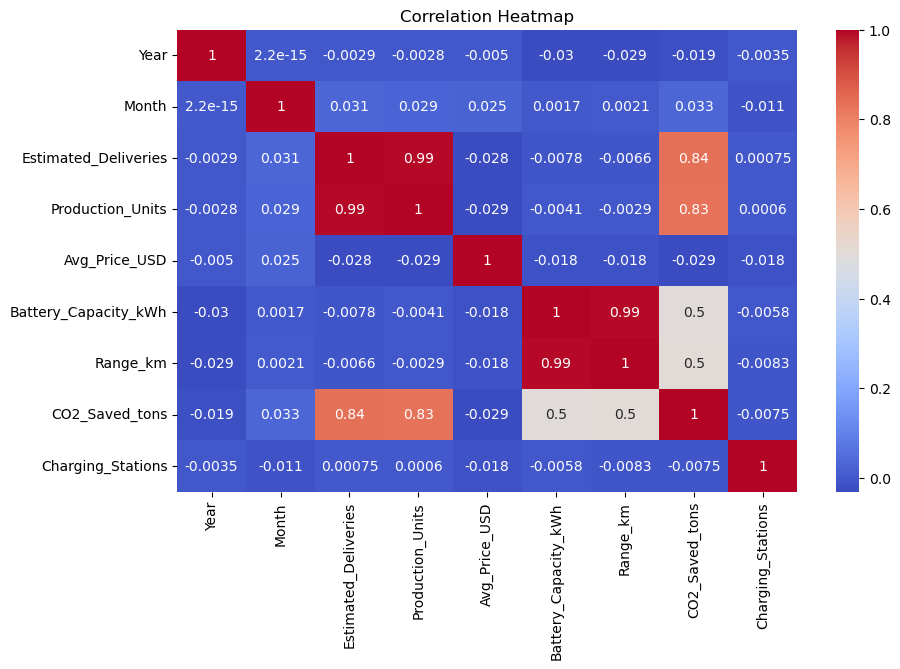

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True) , annot = True , cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

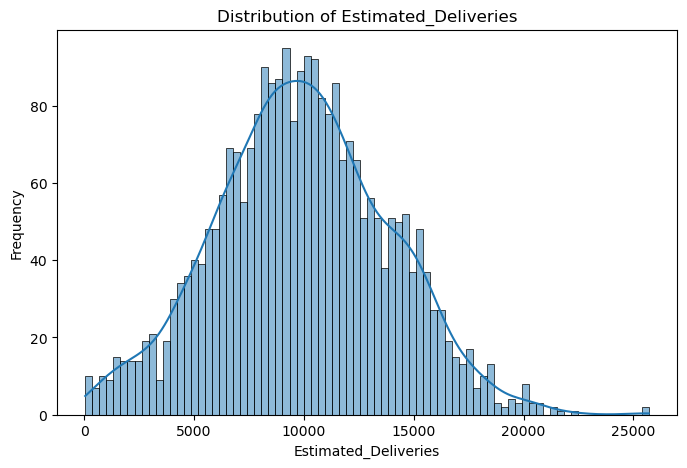

In [45]:
plt.figure(figsize = (8,5))
sns.histplot(df['Estimated_Deliveries'] , bins = 80 , kde = True)
plt.title('Distribution of Estimated_Deliveries')
plt.xlabel('Estimated_Deliveries')
plt.ylabel('Frequency')
plt.show()

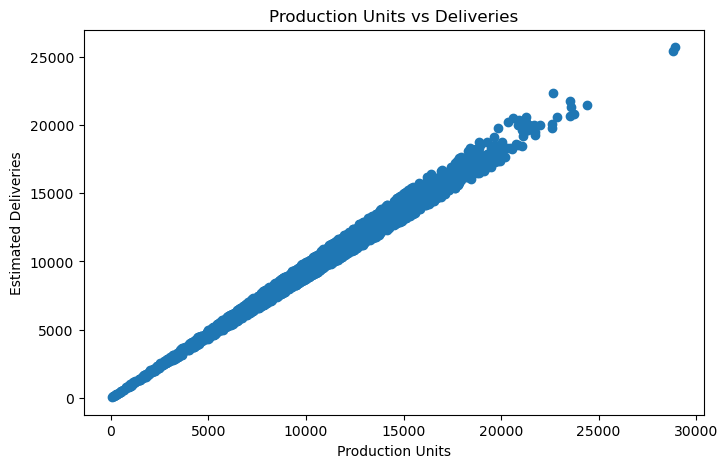

In [46]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Production_Units'],
    df['Estimated_Deliveries']
)

plt.title("Production Units vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

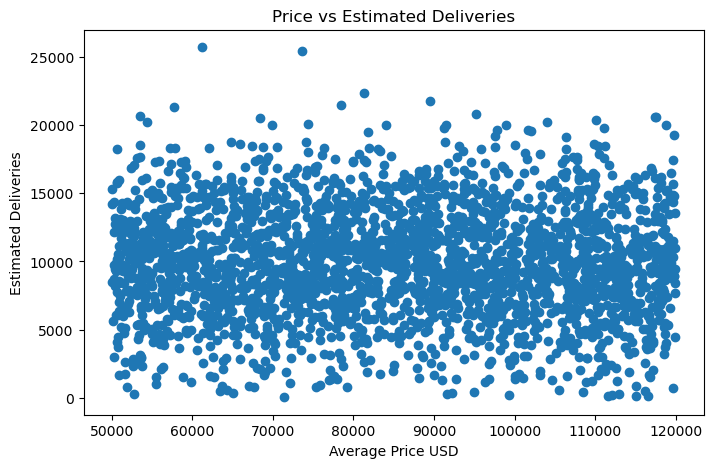

In [47]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Avg_Price_USD'],
    df['Estimated_Deliveries']
)

plt.title("Price vs Estimated Deliveries")
plt.xlabel("Average Price USD")
plt.ylabel("Estimated Deliveries")

plt.show()


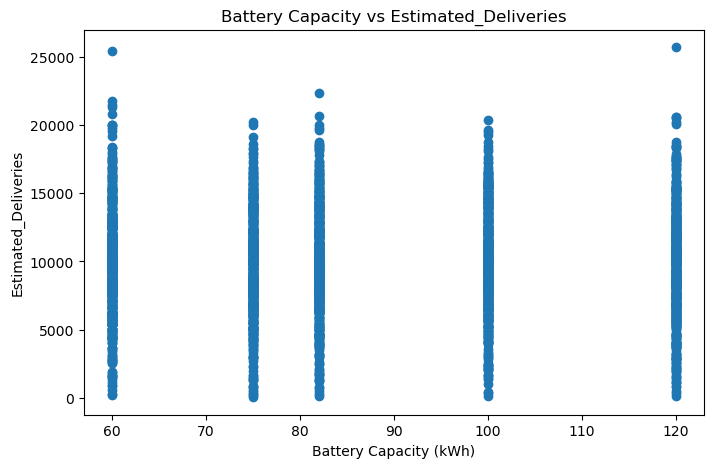

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Battery_Capacity_kWh'],
    df['Estimated_Deliveries']
)

plt.title("Battery Capacity vs Estimated_Deliveries")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Estimated_Deliveries")

plt.show()


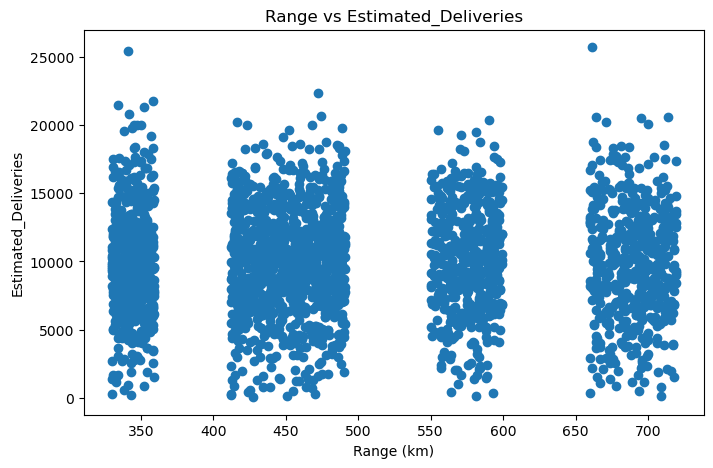

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Range_km'],
    df['Estimated_Deliveries']
)

plt.title("Range vs Estimated_Deliveries")
plt.xlabel("Range (km)")
plt.ylabel("Estimated_Deliveries")

plt.show()

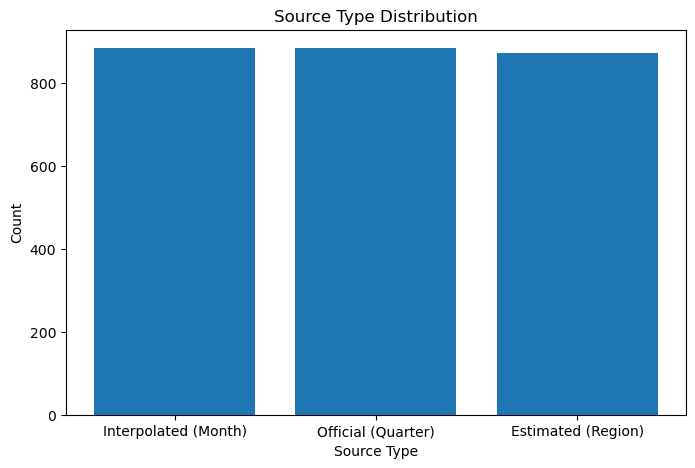

In [50]:
source_count = df['Source_Type'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(source_count.index, source_count.values)

plt.title("Source Type Distribution")
plt.xlabel("Source Type")
plt.ylabel("Count")

plt.show()



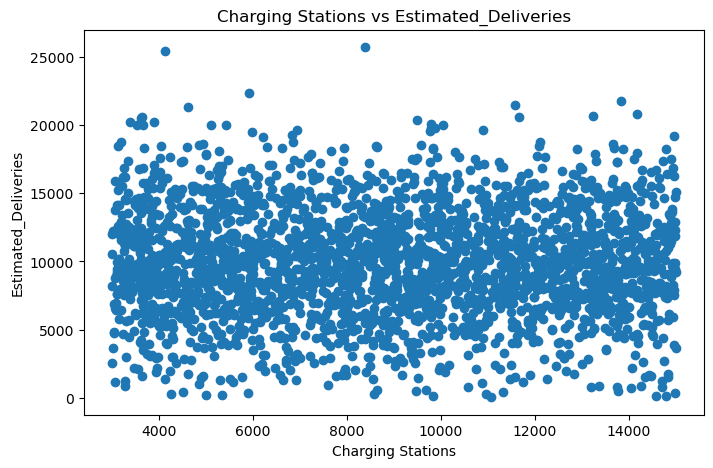

In [51]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Charging_Stations'],
    df['Estimated_Deliveries']
)

plt.title("Charging Stations vs Estimated_Deliveries")
plt.xlabel("Charging Stations")
plt.ylabel("Estimated_Deliveries")

plt.show()



<Figure size 800x500 with 0 Axes>

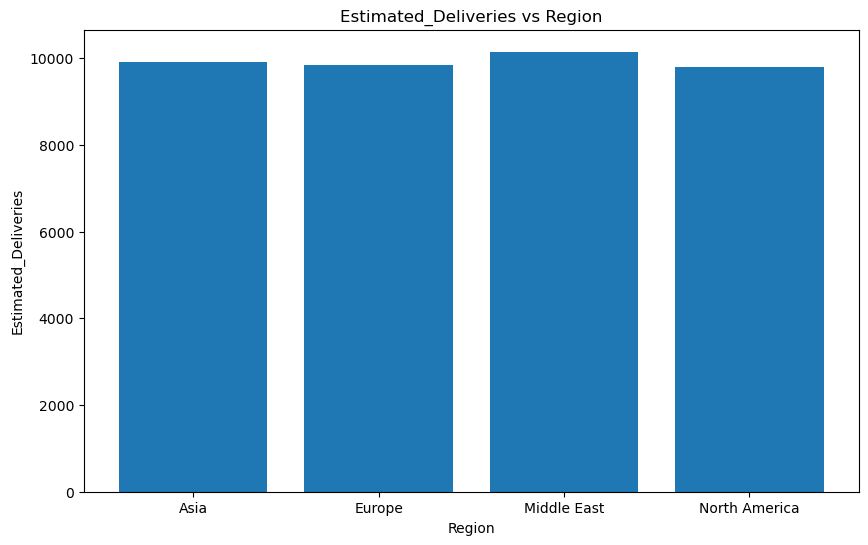

In [52]:
plt.figure(figsize = (8,5))
region_price = df.groupby('Region')['Estimated_Deliveries'].mean()

plt.figure(figsize=(10,6))

plt.bar(region_price.index, region_price.values)

plt.title('Estimated_Deliveries vs Region')
plt.xlabel('Region')
plt.ylabel('Estimated_Deliveries')
plt.show()

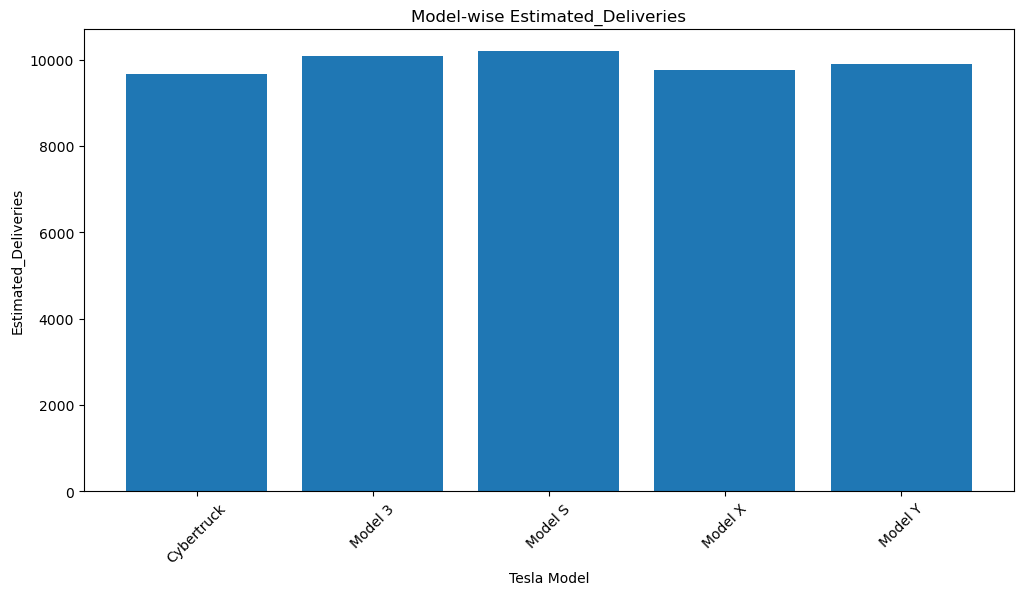

In [53]:
model_price = df.groupby('Model')['Estimated_Deliveries'].mean()

plt.figure(figsize=(12,6))

plt.bar(model_price.index, model_price.values)

plt.title("Model-wise Estimated_Deliveries")
plt.xlabel("Tesla Model")
plt.ylabel("Estimated_Deliveries")

plt.xticks(rotation=45)
plt.show()


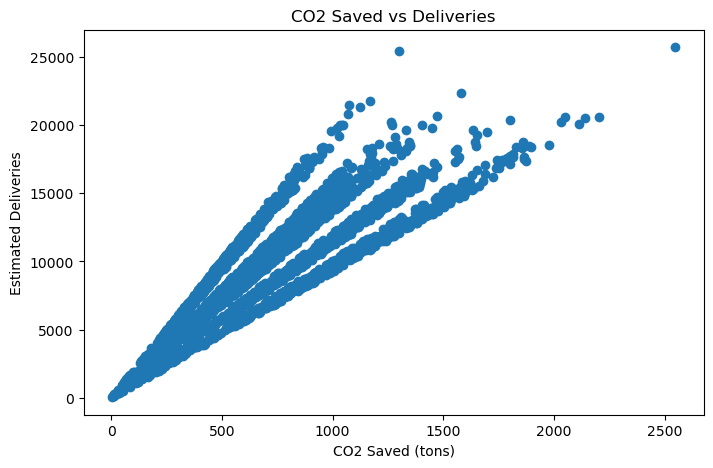

In [54]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['CO2_Saved_tons'],
    df['Estimated_Deliveries']
)

plt.title("CO2 Saved vs Deliveries")
plt.xlabel("CO2 Saved (tons)")
plt.ylabel("Estimated Deliveries")

plt.show()


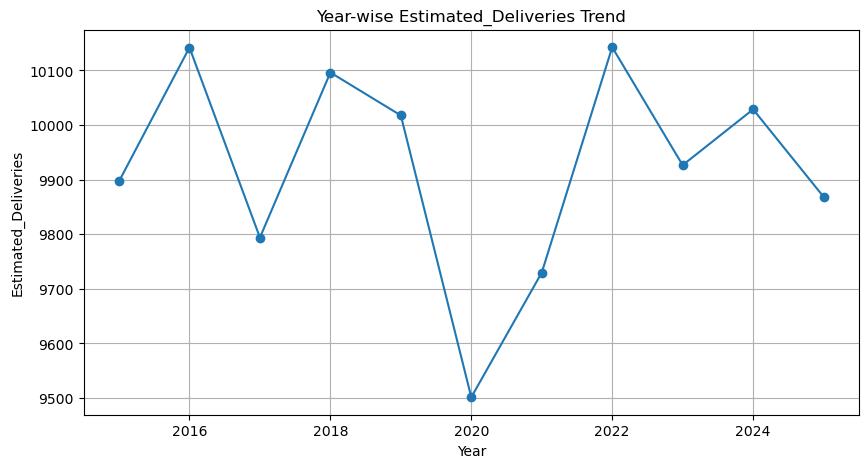

In [55]:
yearly_price = df.groupby('Year')['Estimated_Deliveries'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_price.index,
    yearly_price.values,
    marker='o'
)

plt.title("Year-wise Estimated_Deliveries Trend")
plt.xlabel("Year")
plt.ylabel("Estimated_Deliveries")

plt.grid(True)

plt.show()

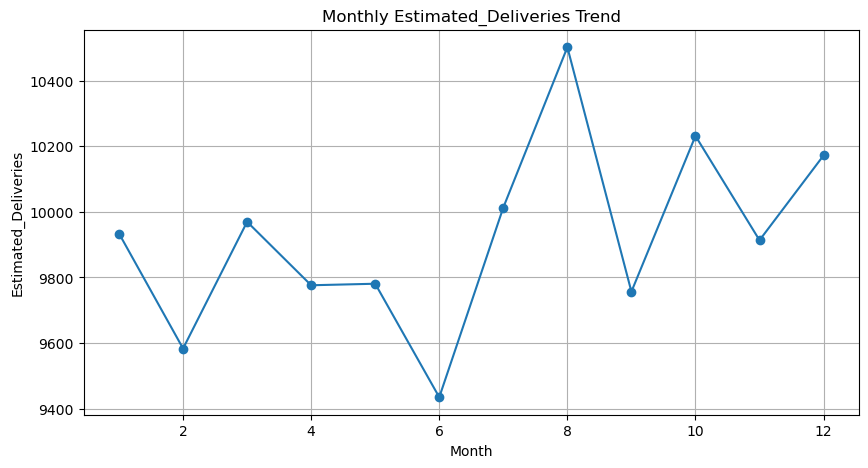

In [56]:

monthly_price = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    marker='o'
)

plt.title("Monthly Estimated_Deliveries Trend")
plt.xlabel("Month")
plt.ylabel("Estimated_Deliveries")

plt.grid(True)

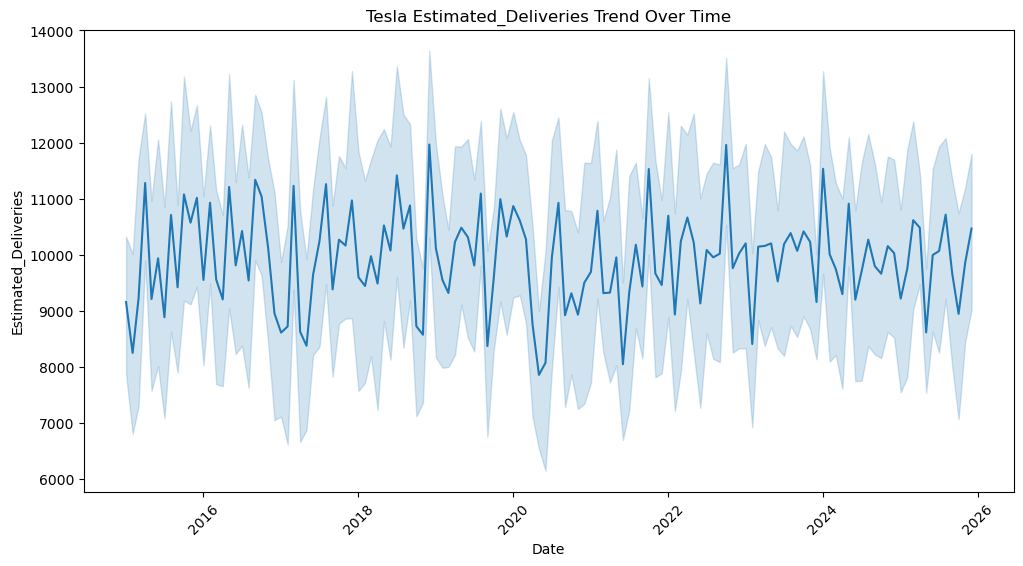

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Estimated_Deliveries Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated_Deliveries")

plt.xticks(rotation=45)

plt.show()

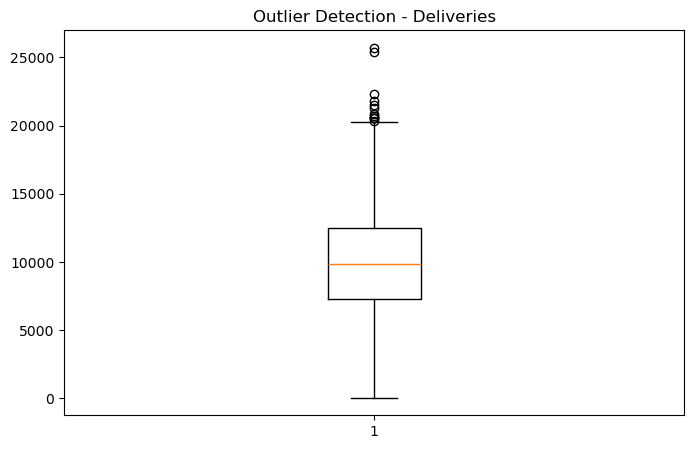

In [58]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Estimated_Deliveries'])

plt.title("Outlier Detection - Deliveries")

plt.show()


#**Feature Engineering** #


In [59]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Estimated_Deliveries'].quantile(0.25)
Q3 = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define acceptable bounds (Standard 1.5 * IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the DataFrame to remove outlier rows
initial_shape = df.shape[0]
df = df[(df['Estimated_Deliveries'] >= lower_bound) & (df['Estimated_Deliveries'] <= upper_bound)]
final_shape = df.shape[0]

print(f"Outlier Removal Complete!")
print(f"Removed {initial_shape - final_shape} anomalous rows.")
print(f"New dataset row count: {final_shape}")

Outlier Removal Complete!
Removed 12 anomalous rows.
New dataset row count: 2628


In [60]:
# 1. Create a production gap feature
df['Production_Gap'] = df['Production_Units'] - df['Estimated_Deliveries']

# 2. Create a delivery-to-infrastructure ratio feature
df['Deliveries_per_Station'] = df['Estimated_Deliveries'] / df['Charging_Stations']

In [61]:
# We drop 'Estimated_Deliveries' (target) and 'Date' (datetime object)
# We also drop 'Production_Units' and 'CO2_Saved_tons' to eliminate heavy multicollinearity
y = df['Estimated_Deliveries']
X = df.drop(columns=['Estimated_Deliveries', 'Date', 'Production_Units', 'CO2_Saved_tons'])


In [62]:
# - Apply StandardScaler to normalize numerical feature ranges.
# - Apply OneHotEncoder to categorical features ('Region', 'Model', 'Source_Type').

numeric_features = [
    'Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'Charging_Stations', 'Production_Gap', 'Deliveries_per_Station'
]
categoricalColumns = ['Region', 'Model', 'Source_Type']

In [63]:
columnTransform = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricalColumns)
    ]
)


# **Model Training With HyperParameter Tunning**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
pipeline = Pipeline(steps=[
    ('preprocessor', columnTransform),
    ('regressor', LinearRegression())
])


In [66]:
param_grid = [
    # Option A: Plain Linear Regression (No hyperparameter tuning needed)
    {
        'regressor': [LinearRegression()]
    },
    # Option B: L1 Regularization (Lasso) + tuning alpha
    {
        'regressor': [Lasso(max_iter=2000)],
        'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    # Option C: L2 Regularization (Ridge) + tuning alpha
    {
        'regressor': [Ridge()],
        'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    # Option D : RandomForestRegression
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 4, 5],
        'regressor__min_samples_split': [15, 20],
        'regressor__min_samples_leaf': [10, 15]
    }

]

In [67]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [68]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'Charging_Stations',
                                                                          'Production_Gap',
                                                                          'Deliveries_per_Station']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('regressor', LinearRe...
                         {'regressor': [Lasso(max_iter=2000)],
                          'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
                         {'regressor': [Ridge()],
                          'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
                         {'regressor': [RandomForestRegressor(random_state=42)],
                          'regressor__max_depth': [3, 4, 5],
                          'regressor__min_samples_leaf': [10, 15],
                          'regressor__min_samples_split': [15, 20],
                          'regressor__n_estimators': [100, 200]}],
             scoring='r2')

# **Choose Best Model and Evaluate on data**

In [69]:
best_pipeline = grid_search.best_estimator_

# Lets evaluate on training data




In [70]:
y_pred_train = best_pipeline.predict(X_train)

In [71]:
print(f"R2 Score on Training Data: {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE on Training Data: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"MSE on Training Data: {mean_squared_error(y_train, y_pred_train):.2f}")

R2 Score on Training Data: 0.8817
RMSE on Training Data: 1339.00
MSE on Training Data: 1792911.14


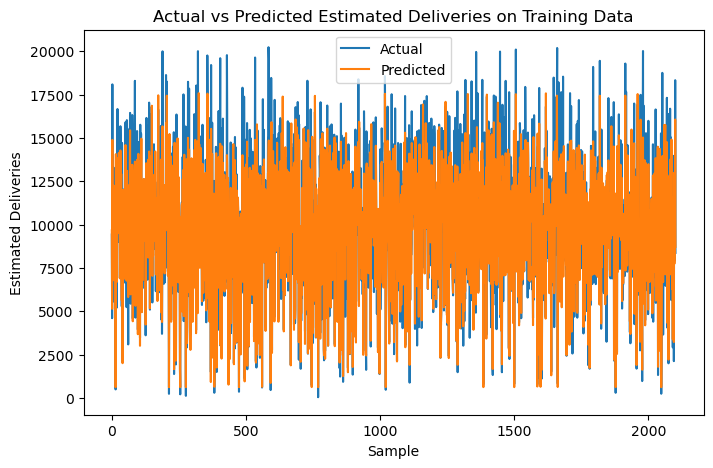

In [72]:
plt.figure(figsize = (8,5))
plt.plot(y_train.values , label = 'Actual')
plt.plot(y_pred_train , label = 'Predicted')
plt.legend()
plt.title('Actual vs Predicted Estimated Deliveries on Training Data')
plt.xlabel('Sample')
plt.ylabel('Estimated Deliveries')
plt.show()

# Lets evaluate on Testing data



In [73]:
y_pred_final = best_pipeline.predict(X_test)


In [74]:
print(f"Final Tuned R2 Score: {r2_score(y_test, y_pred_final):.4f}")
print(f"Final Tuned RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}")
print(f"Final Tuned MSE: {mean_squared_error(y_test, y_pred_final):.2f}")

Final Tuned R2 Score: 0.8670
Final Tuned RMSE: 1353.48
Final Tuned MSE: 1831917.69


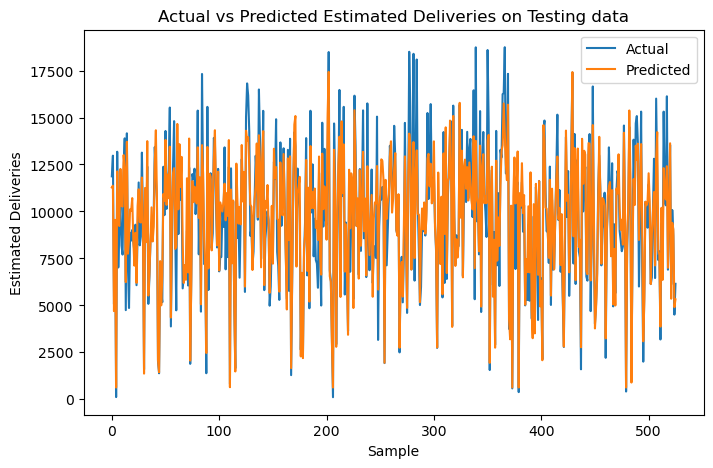

In [75]:
plt.figure(figsize = (8,5))
plt.plot(y_test.values , label = 'Actual')
plt.plot(y_pred_final , label = 'Predicted')
plt.legend()
plt.title('Actual vs Predicted Estimated Deliveries on Testing data')
plt.xlabel('Sample')
plt.ylabel('Estimated Deliveries')
plt.show()



---



---



# **Time Series Forecasting**




---


---



In [76]:
# Ensure 'Date' is datetime and set as index for time-series operations
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date') # Ensure df is sorted by date
df.set_index('Date', inplace=True)

# Feature Engineering for Time Series Forecasting

In [77]:
# Add lag features to df
df['lag_1'] = df['Estimated_Deliveries'].shift(1)

df['lag_1'].fillna(
    df["lag_1"].mean(),
    inplace=True
)

df['lag_2'] = df['Estimated_Deliveries'].shift(2)

df['lag_2'].fillna(
    df["lag_2"].mean(),
    inplace=True
)

df['lag_3'] = df['Estimated_Deliveries'].shift(3)


df['lag_3'].fillna(
    df["lag_3"].mean(),
    inplace=True
)


In [78]:
# Add rolling feature to df
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .shift(1)
    .rolling(window=3)
    .mean()
)
df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

In [79]:
# Drop rows with NaN values created by shifting
df.dropna(inplace=True)

In [80]:
# Define X_ts and y_ts from the prepared df
X_ts = df.drop(
    columns=[
        'Estimated_Deliveries', 'CO2_Saved_tons', 'Production_Units']
)
y_ts = df['Estimated_Deliveries']

In [81]:
X_ts.columns

Index(['Year', 'Month', 'Region', 'Model', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'Source_Type', 'Charging_Stations',
       'Production_Gap', 'Deliveries_per_Station', 'lag_1', 'lag_2', 'lag_3',
       'Rolling_Mean_3'],
      dtype='object')

In [82]:
# CHRONOLOGICAL TRAIN-TEST SPLIT : Take first 80% for training and last 20% for future testing
split_idx = int(len(X_ts) * 0.8)

X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

# Ensure dates align with the X_ts and y_ts splits, now using the index of X_ts
dates_train = X_train_ts.index
dates_test = X_test_ts.index

In [83]:
numerical_features_ts = [
    'Year', 'Month', 'Avg_Price_USD', 'Charging_Stations', 'Battery_Capacity_kWh',
    'Range_km', 'lag_2', 'lag_3', 'lag_1', 'Rolling_Mean_3', 'Production_Gap', 'Deliveries_per_Station'
]

categoricalColumns = ['Region', 'Model', 'Source_Type']

In [84]:
preprocessor_ts = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_ts),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricalColumns)
    ]
)

# Model Pipelining with Time Series cross validation and Tunning

In [85]:
pipeline_ts = Pipeline(steps=[
    ('preprocessor', preprocessor_ts),
    ('regressor', LinearRegression())
])

In [86]:
# TimeSeriesSplit ensures validation sets always chronologically follow training sets
tscv = TimeSeriesSplit(n_splits=3)

In [87]:
param_grid_ts = [
    # 1. Plain Linear Regression (No hyperparameters to tune)
    {
        'regressor': [LinearRegression()]
    },
    # 2. Lasso Regression (L1 Penalty)
    {
        'regressor': [Lasso(max_iter=5000, random_state=42)],
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0 ,500.0 ,50.0]
    },
    # 3. Ridge Regression (L2 Penalty)
    {
        'regressor': [Ridge(random_state=42)],
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0 ,50.0 , 500.0]
    },
    # 4 . RandomForestRegression
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 4, 5],
        'regressor__min_samples_split': [15, 20],
        'regressor__min_samples_leaf': [10, 15]
    }
]

In [88]:
grid_search_ts = GridSearchCV(
    estimator=pipeline_ts,
    param_grid=param_grid_ts,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

In [89]:
grid_search_ts.fit(X_train_ts, y_train_ts)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Avg_Price_USD',
                                                                          'Charging_Stations',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'lag_2',
                                                                          'lag_3',
                                                                          'lag_1',
                                                                          'Rolling_Mean_3',
                                                                          'Production_Gap',
                                                                          'Deliveries_per_Station...
                          'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 500.0,
                                               50.0]},
                         {'regressor': [Ridge(random_state=42)],
                          'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 50.0,
                                               500.0]},
                         {'regressor': [RandomForestRegressor(random_state=42)],
                          'regressor__max_depth': [3, 4, 5],
                          'regressor__min_samples_leaf': [10, 15],
                          'regressor__min_samples_split': [15, 20],
                          'regressor__n_estimators': [100, 200]}],
             scoring='r2')

# Find best Model and Evaluate for Time Series Forecasting

In [90]:
best_model_ts = grid_search_ts.best_estimator_

In [91]:
# Generate predictions for both splits
y_pred_ts_train = best_model_ts.predict(X_train_ts)
y_pred_ts_test = best_model_ts.predict(X_test_ts)

# Evaluation on Training data

In [92]:
print(f"R2 Score on training data: {r2_score(y_train_ts , y_pred_ts_train):.4f}")
print(f"RMSE on training data: {np.sqrt(mean_squared_error(y_train_ts , y_pred_ts_train)):.2f}")
print(f"MSE on training data: {mean_squared_error(y_train_ts , y_pred_ts_train):.2f}")

R2 Score on training data: 0.8779
RMSE on training data: 1364.89
MSE on training data: 1862936.93


<Figure size 640x480 with 0 Axes>

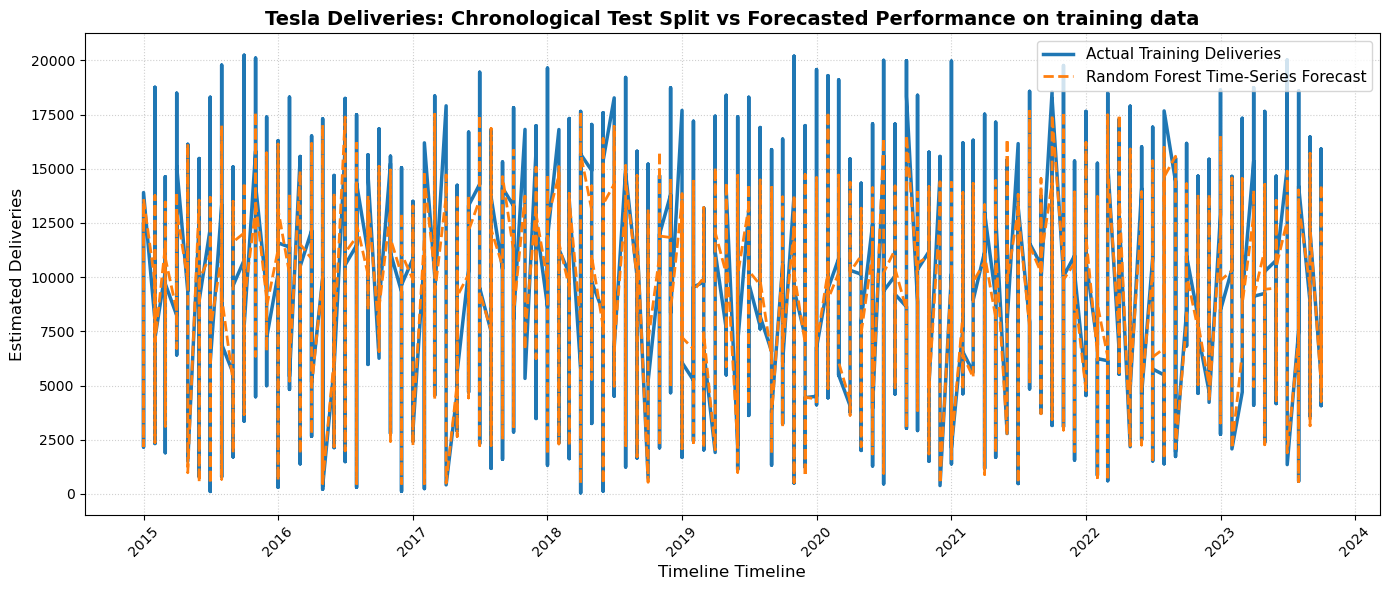

In [98]:
plt.clf()

plt.figure(figsize=(14, 6))
plt.plot(dates_train, y_train_ts.values, label='Actual Training Deliveries', color='tab:blue', linewidth=2.5)
plt.plot(dates_train, y_pred_ts_train, label='Random Forest Time-Series Forecast', color='tab:orange', linestyle='--', linewidth=2)

plt.title('Tesla Deliveries: Chronological Test Split vs Forecasted Performance on training data', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Timeline', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Evaluation on Testing data

In [94]:
print(f"R2 Score on testing data: {r2_score(y_test_ts ,y_pred_ts_test):.4f}")
print(f"RMSE on testing data: {np.sqrt(mean_squared_error(y_test_ts,y_pred_ts_test)):.2f}")
print(f"MSE on testing data: {mean_squared_error(y_test_ts ,y_pred_ts_test):.2f}")

R2 Score on testing data: 0.8555
RMSE on testing data: 1392.71
MSE on testing data: 1939653.69


<Figure size 640x480 with 0 Axes>

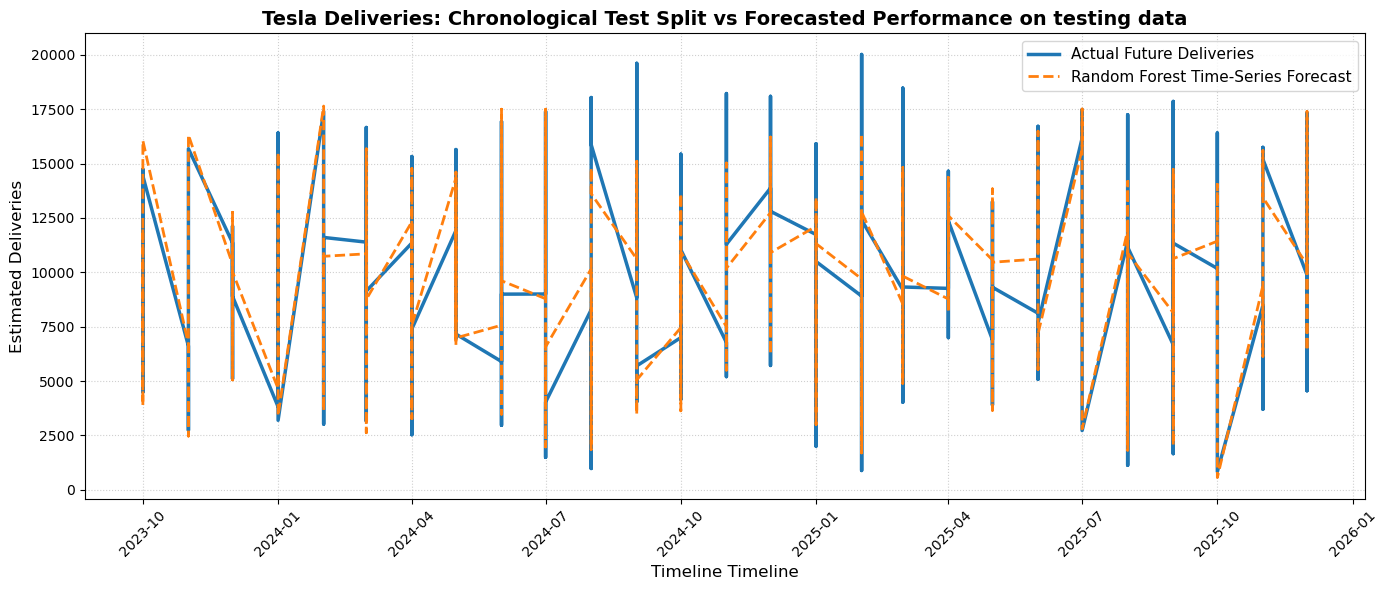

In [99]:
plt.clf()

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test_ts.values, label='Actual Future Deliveries', color='tab:blue', linewidth=2.5)
plt.plot(dates_test, y_pred_ts_test, label='Random Forest Time-Series Forecast', color='tab:orange', linestyle='--', linewidth=2)

plt.title('Tesla Deliveries: Chronological Test Split vs Forecasted Performance on testing data', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Timeline', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final Project Conclusion

### 1. Performance Summary Across Pipelines
* **Standard ML Pipeline (Random Split):**
  * Training $R^2$ Score: **0.8817**
  * Testing $R^2$ Score: **0.8670**
* **Time-Series Pipeline (Chronological Split):**
  * Training $R^2$ Score: **0.8779**
  * Testing $R^2$ Score: **0.8555**

### 2. Model Diagnostics & Fit Assessment
* **Excellent Generalization:** The minimal performance gap between training and testing data (~1.5% for standard ML, ~2.2% for Time-Series) demonstrates that the model generalizes robustly to unseen data.
* **Optimal Fit:** High $R^2$ baselines across all partitions indicate that the model successfully captures the core variance in vehicle deliveries without suffering from high variance (overfitting) or high bias (underfitting).
* **Automated Selection Success:** Across both validation frameworks, the automated `GridSearchCV` pipeline successfully rejected simpler linear variants to isolate a regularized **Random Forest Regressor** as the optimal predictive architecture for this dataset.